# **Capstone Project**: Empowering Hidden Creators - Predicting YouTube Video Popularity from Metadata

## __Problem:__ Many YouTube creators struggle to predict how well their videos will perform before publishing, especially those in niche or new channels. This uncertainty makes it difficult to invest time and effort into content creation confidently.
## __Methodologies:__ I built a machine learning model to predict a video's potential popularity using only its metadata (e.g., title, tags, duration, and channel stats). Techniques included TF-IDF vectorization for text features, dimensionality reduction via TruncatedSVD, and training models like Random Forest and Gradient Boosting on a log-transformed view count target.

## __Outcomes:__ The best performing model achieved a reasonable accuracy with an R² of ~0.66 and a mean absolute error of ~0.79 in log-scale. While the model performs well on existing content types, it has limitations in predicting views for entirely new channels. Still, it offers a practical tool for creators to make more data-informed content decisions.

# 1. Import Libraries

In [ ]:
# Core Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# External Data Access
import kagglehub

# 2. Load Data from Kaggle

In [ ]:
# Download latest version
path = kagglehub.dataset_download("canerkonuk/youtube-trending-videos-global")

print("Path to dataset files:", path)

100%|██████████| 2.58G/2.58G [00:37<00:00, 74.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/canerkonuk/youtube-trending-videos-global/versions/300


### Load the CSV

In [ ]:
csv_path = os.path.join(path, "youtube_trending_videos_global.csv")
df = pd.read_csv(csv_path)

/tmp/ipython-input-3647441745.py:2: DtypeWarning: Columns (13,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


### Preview the structure

#### Check number of rows and columns

In [ ]:
df.shape

(4184891, 28)

#### View column names

In [ ]:
df.columns

Index(['video_id', 'video_published_at', 'video_trending__date',
       'video_trending_country', 'channel_id', 'video_title',
       'video_description', 'video_default_thumbnail', 'video_category_id',
       'video_tags', 'video_duration', 'video_dimension', 'video_definition',
       'video_licensed_content', 'video_view_count', 'video_like_count',
       'video_comment_count', 'channel_title', 'channel_description',
       'channel_custom_url', 'channel_published_at', 'channel_country',
       'channel_view_count', 'channel_subscriber_count',
       'channel_have_hidden_subscribers', 'channel_video_count',
       'channel_localized_title', 'channel_localized_description'],
      dtype='object')

#### View first 5 rows

In [ ]:
df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",...,NaN,@jennierubyjane,2021-01-13T06:19:55.86689Z,NaN,464615150.0,11600000.0,False,43.0,JENNIE,NaN
1,5ObJt_71AYc,2024-10-11T02:59:21Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,CHILE vs. BRASIL [1-2] | RESUMEN | ELIMINATORI...,#Chile #Brasil #eliminatoriassudamericanas #Cr...,https://i.ytimg.com/vi/5ObJt_71AYc/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,NaN,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
2,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",...,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110.0,1380000.0,False,314.0,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚
3,SJfoPdeOPCQ,2024-10-11T00:10:10Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,VENEZUELA vs. ARGENTINA [1-1] | RESUMEN | ELIM...,#Venezuela #Argentina #eliminatoriassudamerica...,https://i.ytimg.com/vi/SJfoPdeOPCQ/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,NaN,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
4,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,NaN,...,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,NaN,19991522.0,40600.0,False,56.0,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...


## Clean the data

#### Check number of unique videos

In [ ]:
unique_videos = df['video_id'].nunique()
print(f"Unique videos: {unique_videos}")
print(f"Original rows: {len(df)}")

Unique videos: 152264
Original rows: 4184891


#### Drop duplicates

In [ ]:
# Drop duplicates by video ID (keep latest trending record)
df = df.sort_values('video_trending__date').drop_duplicates('video_id', keep='last')

#### Check new dataframe shape

In [ ]:
df.shape

(152265, 28)

#### Drop rows where view count is missing

In [ ]:
df = df.dropna(subset=['video_view_count'])

#### Drop rows with missing subscriber count

In [ ]:
df = df.dropna(subset=['channel_subscriber_count'])

#### Check new dataframe shape

In [ ]:
df.shape

(152214, 28)

# 3. Feature engineering

### Feature: 'video_duration_sec'

#### View 'video_duration' column

In [ ]:
df['video_duration'].head()

,video_duration
10173,PT2M31S
10183,PT11M54S
9982,PT40M11S
10021,PT9M48S
10026,PT24S


In [ ]:
pip install isodate

In [ ]:
import isodate

def parse_duration(duration_str):
    try:
        return isodate.parse_duration(duration_str).total_seconds()
    except:
        return np.nan

# Apply the function to the column
df['video_duration_sec'] = df['video_duration'].apply(parse_duration)

# Preview the result
df[['video_duration', 'video_duration_sec']].head()


,video_duration,video_duration_sec
10173,PT2M31S,151.0
10183,PT11M54S,714.0
9982,PT40M11S,2411.0
10021,PT9M48S,588.0
10026,PT24S,24.0


### Feature: Video definition (binary)

#### View 'video_definition' column

In [ ]:
df['video_definition'].head()

,video_definition
10173,hd
10183,hd
9982,hd
10021,hd
10026,hd


#### Convert video_definition to binary

In [ ]:
df['is_hd'] = df['video_definition'].map({'hd': 1, 'sd': 0})

### Feature: Title Length

#### Extract video title length

In [ ]:
df['title_length'] = df['video_title'].astype(str).apply(len)

### Feature: Number of tags

#### Extract number of tags

In [ ]:
df['tag_count'] = df['video_tags'].astype(str).apply(lambda x: len(x.split('|')) if x != '[]' else 0)

### Feature: Log-transform view count

In [ ]:
df['log_view_count'] = np.log1p(df['video_view_count'])

### Feature: Tags Text

In [ ]:
# Replace '|' with space
df['tags_text'] = df['video_tags'].fillna('').str.replace('|', ' ', regex=False)


#### Apply TF-IDF Vectorization

In [ ]:
# Tags TF-IDF
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# Fit and transform the tags
tfidf_matrix = tfidf.fit_transform(df['tags_text'])

# Compress using TruncatedSVD
svd_tags = TruncatedSVD(n_components=100, random_state=42)
tags_svd_matrix = svd_tags.fit_transform(tfidf_matrix)

# Convert to DataFrame
tags_svd_df = pd.DataFrame(tags_svd_matrix, columns=[f"tag_topic_{i}" for i in range(1, 101)], index=df.index)

### Feature: Title Text

In [ ]:
df['title_text'] = df['video_title'].fillna('').astype(str)

#### Apply TF-IDF Vectorization

In [ ]:
# Title TF-IDF
title_tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# Fit and transform the tags
title_matrix = title_tfidf.fit_transform(df['title_text'])

# Compress using TruncatedSVD
svd_title = TruncatedSVD(n_components=100, random_state=42)
title_svd_matrix = svd_title.fit_transform(title_matrix)

# Convert to DataFrame
title_svd_df = pd.DataFrame(title_svd_matrix, columns=[f"title_topic_{i}" for i in range(1, 101)], index=df.index)

# Combine with original dataframe
df_tfidf = pd.concat([df, tags_svd_df, title_svd_df], axis=1)


# 4. Exploratory Data Analysis

## Target Variable Distribution (video_view_count)

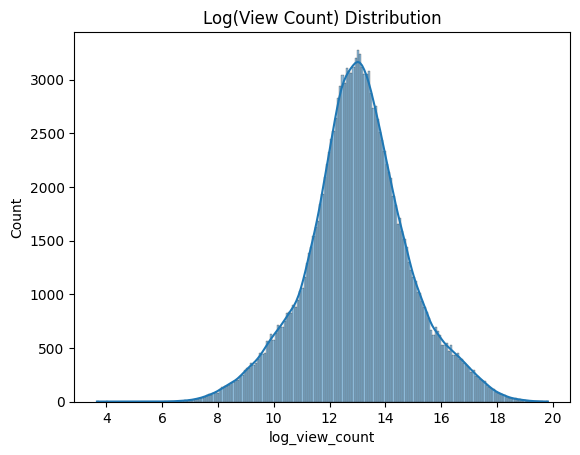

In [ ]:
sns.histplot(df['log_view_count'], kde=True)
plt.title("Log(View Count) Distribution")
plt.show()

## Correlation Heatmap

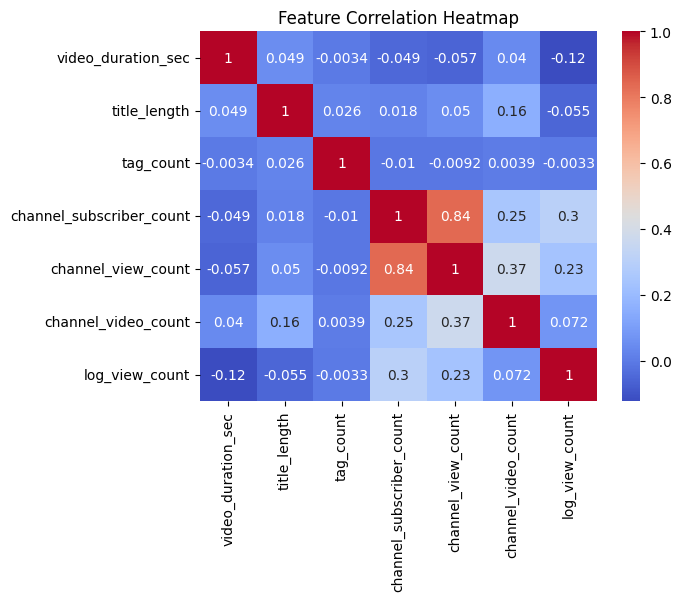

In [ ]:
numeric_features = [
    'video_duration_sec', 'title_length', 'tag_count',
    'channel_subscriber_count', 'channel_view_count',
    'channel_video_count', 'log_view_count'
]

corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Relationship Plots

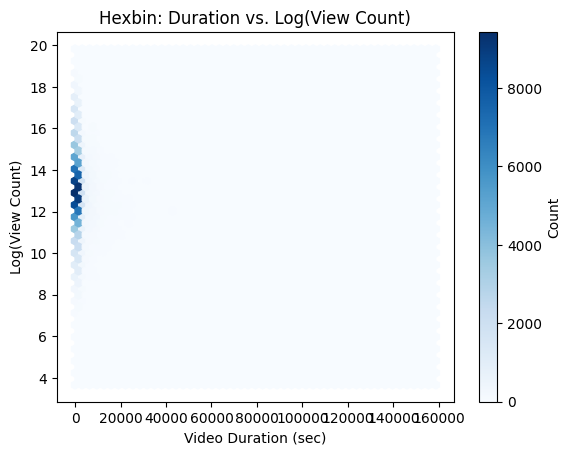

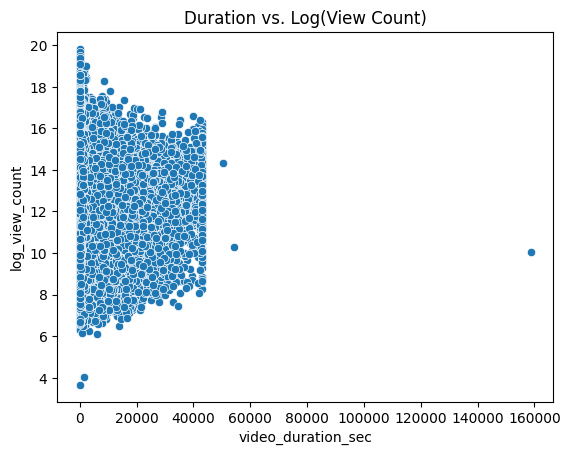

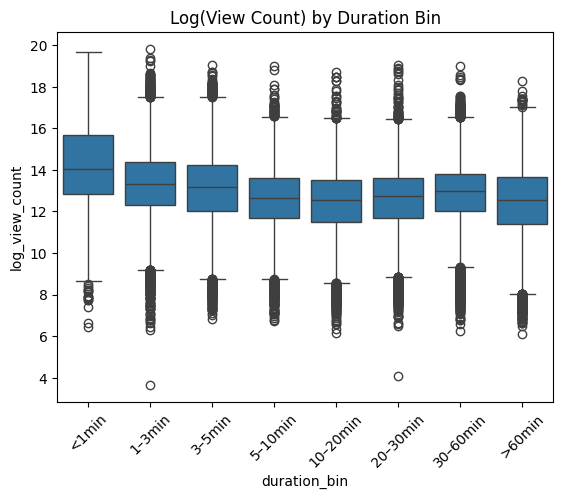

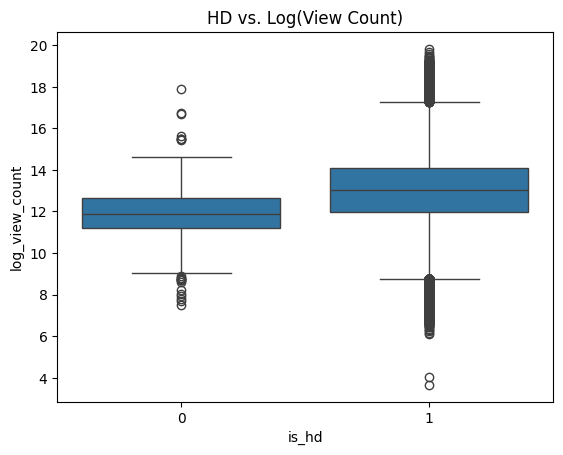

In [ ]:
plt.hexbin(x=df['video_duration_sec'], y=df['log_view_count'], gridsize=50, cmap='Blues')
plt.colorbar(label='Count')
plt.xlabel('Video Duration (sec)')
plt.ylabel('Log(View Count)')
plt.title('Hexbin: Duration vs. Log(View Count)')
plt.show()


sns.scatterplot(data=df, x='video_duration_sec', y='log_view_count')
plt.title("Duration vs. Log(View Count)")
plt.show()

# Create duration bins (e.g., every 2 minutes)
df['duration_bin'] = pd.cut(df['video_duration_sec'], bins=[0, 60, 180, 300, 600, 1200, 1800, 3600, 100000],
                            labels=['<1min', '1–3min', '3–5min', '5–10min', '10–20min', '20–30min', '30–60min', '>60min'])

sns.boxplot(data=df, x='duration_bin', y='log_view_count')
plt.xticks(rotation=45)
plt.title("Log(View Count) by Duration Bin")
plt.show()


sns.boxplot(data=df, x='is_hd', y='log_view_count')
plt.title("HD vs. Log(View Count)")
plt.show()

## Category-Level Analysis

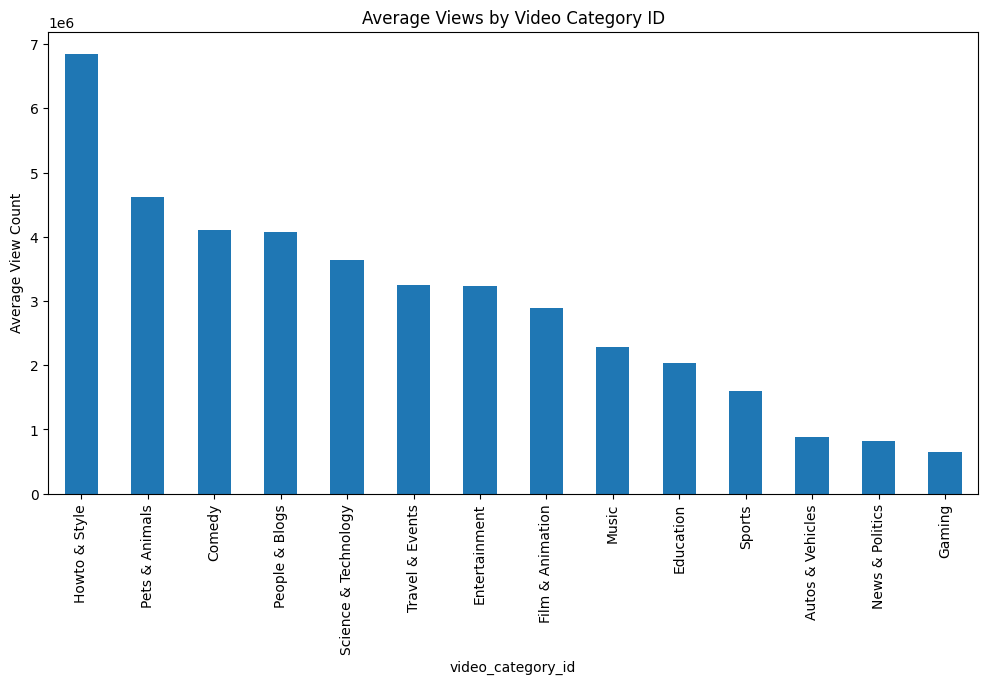

In [ ]:
category_views = df.groupby('video_category_id')['video_view_count'].mean().sort_values(ascending=False)
category_views.plot(kind='bar', figsize=(12,6), title='Average Views by Video Category ID')
plt.ylabel('Average View Count')
plt.show()

# 5. Model Building

## Problem: Regression
## Predicting: Video View Count

## Prepare the Features and Target

In [ ]:
selected_features = [
    'video_duration_sec',
    'title_length',
    'is_hd',
    'channel_subscriber_count',
    'channel_view_count',
    'channel_video_count',
] + list(tags_svd_df.columns) + list(title_svd_df.columns)

X = df_tfidf[selected_features]
y = df_tfidf['log_view_count']

## Split Data into Train-Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

### Remove NaN

In [ ]:
# Combine X and y temporarily for safe dropping
train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.dropna()

X_train_clean = train_data[X_train.columns]
y_train_clean = train_data[y_train.name]

# Repeat for test set if needed
test_data = pd.concat([X_test, y_test], axis=1)
test_data = test_data.dropna()

X_test_clean = test_data[X_test.columns]
y_test_clean = test_data[y_test.name]


In [ ]:
train_data.shape

(121626, 207)

### Random Forest Regressor

In [ ]:
# Train model
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=30,   # fewer trees for speed
    max_depth=15,      # limit depth to prevent overfitting and speed up
    n_jobs=-1          # use all CPU cores
)

rf_model.fit(X_train_clean, y_train_clean)
rf_preds = rf_model.predict(X_test_clean)


#### Evaluation

📊 Random Forest (Optimised)
  RMSE: 1.0596860172832832
  MAE: 0.7861520455812266
  R² Score: 0.6577124662725573
----------------------------------------


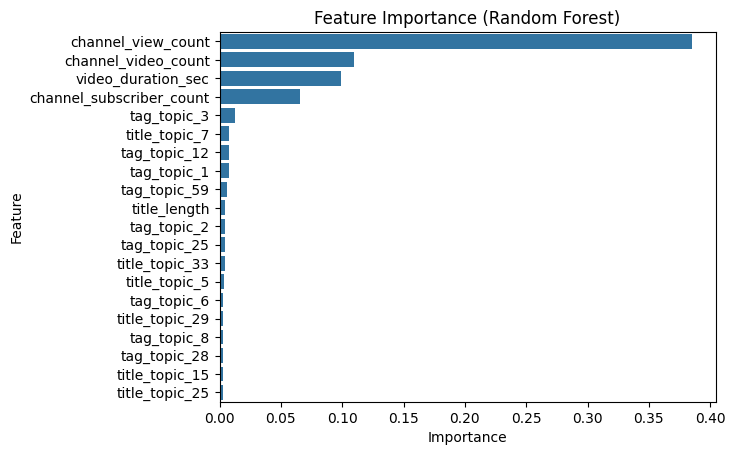

In [ ]:
print("📊 Random Forest (Optimised)")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_clean, rf_preds)))
print("  MAE:", mean_absolute_error(y_test_clean, rf_preds))
print("  R² Score:", r2_score(y_test_clean, rf_preds))
print("-" * 40)

# Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

sns.barplot(data=feature_importance_df.head(20), x='Importance', y='Feature')  # Top 20
plt.title("Feature Importance (Random Forest)")
plt.show()

## Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_clean, y_train_clean)
lr_preds = lr_model.predict(X_test_clean)

print("📊 Linear Regression")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_clean, lr_preds)))
print("  MAE:", mean_absolute_error(y_test_clean, lr_preds))
print("  R² Score:", r2_score(y_test_clean, lr_preds))
print("-" * 40)

📊 Linear Regression
  RMSE: 1.7122743976373407
  MAE: 1.299558628625966
  R² Score: 0.10631719747081414
----------------------------------------


## Gradient Boosting Regressor

In [ ]:
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100)
gb_model.fit(X_train_clean, y_train_clean)
gb_preds = gb_model.predict(X_test_clean)

print("📊 Gradient Boosting")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_clean, gb_preds)))
print("  MAE:", mean_absolute_error(y_test_clean, gb_preds))
print("  R² Score:", r2_score(y_test_clean, gb_preds))
print("-" * 40)

📊 Gradient Boosting
  RMSE: 1.183545921965429
  MAE: 0.9070457756784133
  R² Score: 0.5730206208994799
----------------------------------------


## XGBoost

In [ ]:
# Install libraries
!pip install xgboost lightgbm

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_clean, y_train_clean)
xgb_preds = xgb_model.predict(X_test_clean)

print("📊 XGBoost Regressor")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_clean, xgb_preds)))
print("  MAE:", mean_absolute_error(y_test_clean, xgb_preds))
print("  R² Score:", r2_score(y_test_clean, xgb_preds))
print("-" * 40)


📊 XGBoost Regressor
  RMSE: 1.0926625050190748
  MAE: 0.8248563417225669
  R² Score: 0.6360776272060998
----------------------------------------


## LightGBM

In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_clean, y_train_clean)
lgbm_preds = lgbm_model.predict(X_test_clean)

print("📊 LightGBM Regressor")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_clean, lgbm_preds)))
print("  MAE:", mean_absolute_error(y_test_clean, lgbm_preds))
print("  R² Score:", r2_score(y_test_clean, lgbm_preds))
print("-" * 40)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.768515 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 52123
[LightGBM] [Info] Number of data points in the train set: 121626, number of used features: 206
[LightGBM] [Info] Start training from score 13.012202
📊 LightGBM Regressor
  RMSE: 1.1082813328971572
  MAE: 0.8398264998144085
  R² Score: 0.6255992488924439
----------------------------------------


## Visualise comparison of scores

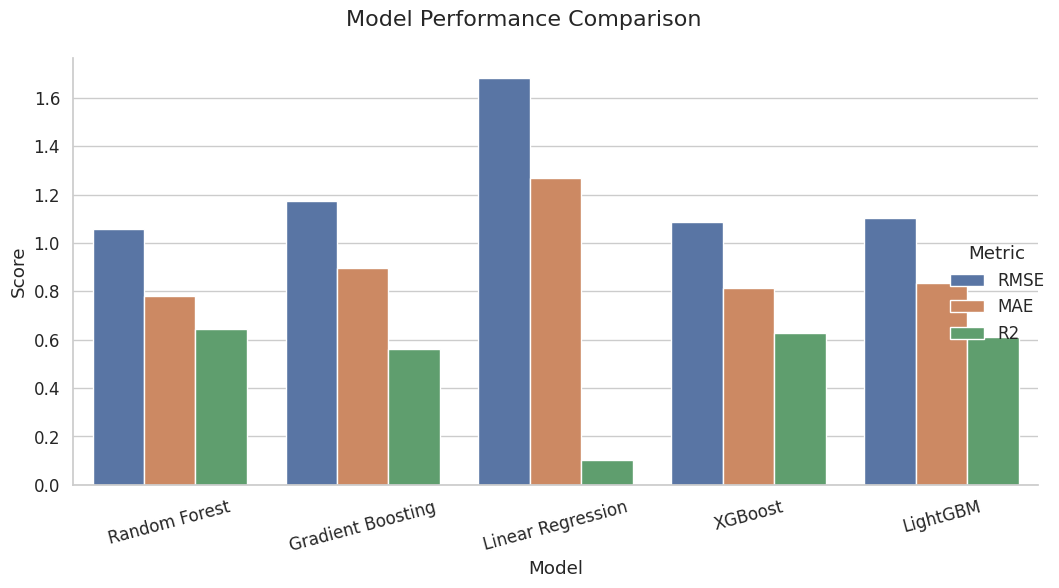

In [ ]:
# Define model names and their scores
model_scores = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Linear Regression",
        "XGBoost",
        "LightGBM"
    ],
    "RMSE": [
        1.0580,
        1.1747,
        1.6811,
        1.0853,
        1.1048
    ],
    "MAE": [
        0.7816,
        0.8977,
        1.2674,
        0.8144,
        0.8333
    ],
    "R2": [
        0.6450,
        0.5624,
        0.1037,
        0.6264,
        0.6129
    ]
})

# Melt the DataFrame for plotting
melted_scores = model_scores.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create a barplot for each metric
sns.set(style="whitegrid", font_scale=1.1)
g = sns.catplot(
    data=melted_scores, kind="bar",
    x="Model", y="Score", hue="Metric",
    height=6, aspect=1.6
)
g.fig.suptitle("Model Performance Comparison", fontsize=16)
g.set_axis_labels("Model", "Score")
g.set_titles("{col_name}")
plt.xticks(rotation=15)
plt.tight_layout()
plt.subplots_adjust(top=0.9)


## Interpret MAE scores

In [ ]:
# MAE values
mae_values = [0.7816, 0.8977, 1.2674, 0.8144, 0.8333]

# Convert log error to multiplicative error: exp(MAE) - 1
percent_errors = [(np.expm1(mae) * 100) for mae in mae_values]

# Round and display
for i, (log_mae, perc) in enumerate(zip(mae_values, percent_errors), 1):
    print(f"Model {i}: MAE = {log_mae:.4f} → ±{perc:.1f}% error in views")

Model 1: MAE = 0.7816 → ±118.5% error in views
Model 2: MAE = 0.8977 → ±145.4% error in views
Model 3: MAE = 1.2674 → ±255.2% error in views
Model 4: MAE = 0.8144 → ±125.8% error in views
Model 5: MAE = 0.8333 → ±130.1% error in views


## Residual Plot

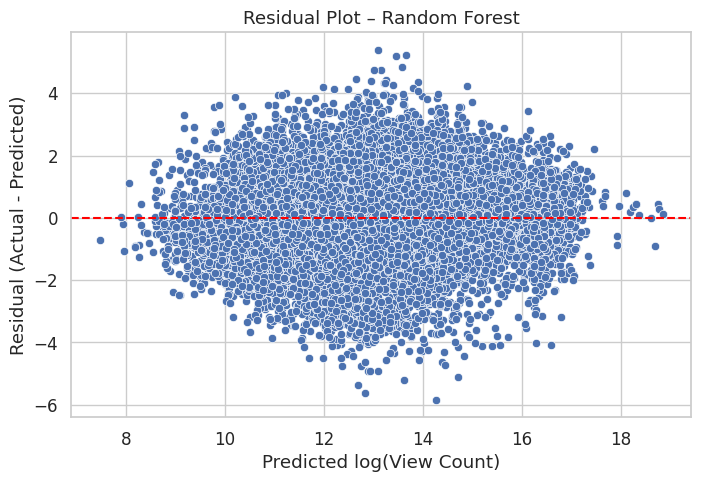

In [ ]:
# Predict on test set
y_pred = rf_model.predict(X_test_clean)

# Residuals
residuals = y_test_clean - y_pred

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted log(View Count)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot – Random Forest")
plt.show()

# 6. Create Function for Test Cases

## Function to predict views

In [ ]:
def predict_views_from_metadata(input_dict, model, tfidf, svd_tags, title_tfidf, svd_title,
                                 tags_svd_columns, title_svd_columns):

    # Convert dict to DataFrame
    new_df = pd.DataFrame([input_dict])

    # TF-IDF + SVD for tags
    tags_vec = tfidf.transform(new_df['tags_text'])
    tags_svd = svd_tags.transform(tags_vec)
    tags_df = pd.DataFrame(tags_svd, columns=tags_svd_columns)

    # TF-IDF + SVD for title
    title_vec = title_tfidf.transform(new_df['title_text'])
    title_svd = svd_title.transform(title_vec)
    title_df = pd.DataFrame(title_svd, columns=title_svd_columns)

    # Select numeric features
    numeric_features = new_df[[
        'video_duration_sec',
        'title_length',
        'is_hd',
        'channel_subscriber_count',
        'channel_view_count',
        'channel_video_count'
    ]]

    # Combine all
    full_input = pd.concat([numeric_features, tags_df, title_df], axis=1)

    # Predict log-views → views
    log_pred = model.predict(full_input)[0]
    view_pred = np.expm1(log_pred)

    return view_pred


## Case 1

### Define input

In [ ]:
new_input = {
    'video_duration_sec': 300,
    'title_length': 45,
    'title_text': "Epic clay art tutorial with satisfying sounds",
    'tags_text': "art|clay|satisfying|tutorial|asmr",
    'is_hd': 1,
    'channel_subscriber_count': 1200,
    'channel_view_count': 50000,
    'channel_video_count': 48
}

### Run predict views function

In [ ]:
# Predict
predicted_views = predict_views_from_metadata(new_input, rf_model, tfidf, svd_tags,
                                              title_tfidf, svd_title,
                                              tags_svd_df.columns, title_svd_df.columns)
print(f"📈 Predicted Views: {predicted_views:,.0f}")


📈 Predicted Views: 24,060


## Case 2

### Define input

In [ ]:
new_input = {
    'video_duration_sec': 210,  # 3.5 minutes – short and punchy
    'title_text': "Taylor Swift & Selena Gomez Surprise Duet – Live at Coachella 2025!",
    'tags_text': "taylor swift|selena gomez|coachella|live performance|duet|concert|music|viral",
    'is_hd': 1,
    'channel_subscriber_count': 5_000_000,
    'channel_view_count': 1_200_000_000,
    'channel_video_count': 320,
    'title_length': len("Taylor Swift & Selena Gomez Surprise Duet – Live at Coachella 2025!")
}

In [ ]:
# Predict
predicted_views = predict_views_from_metadata(new_input, rf_model, tfidf, svd_tags,
                                              title_tfidf, svd_title,
                                              tags_svd_df.columns, title_svd_df.columns)
print(f"📈 Predicted Views: {predicted_views:,.0f}")


📈 Predicted Views: 1,256,448


# 7. SHapley Additive exPlanations

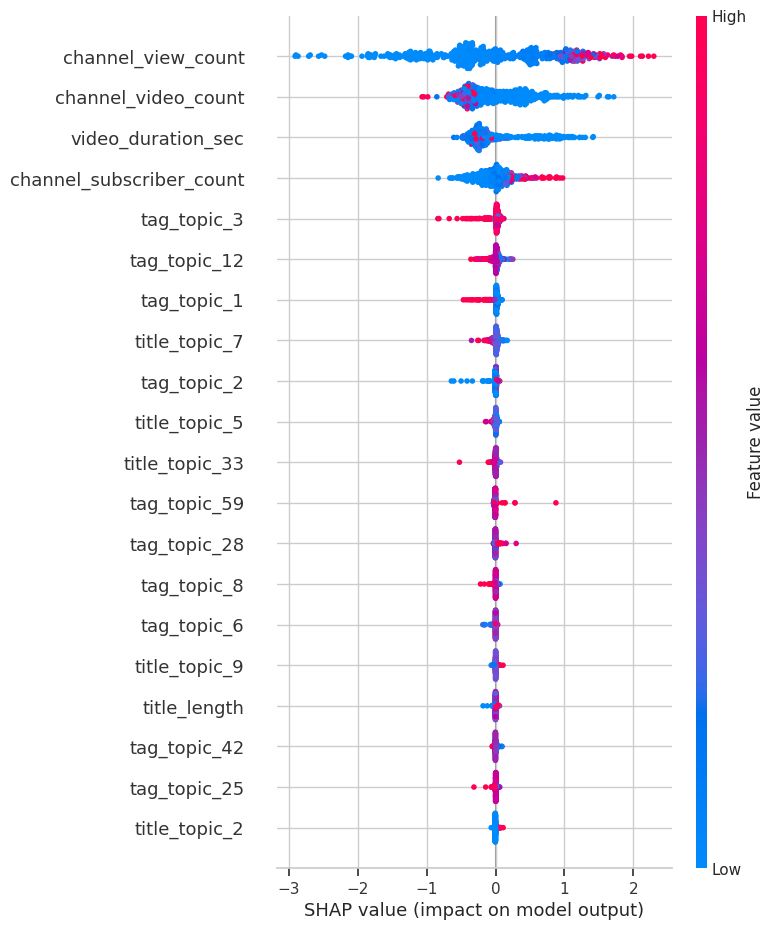

In [ ]:
import shap

# Step 1: Create a SHAP explainer for the Random Forest
explainer = shap.TreeExplainer(rf_model)

# Step 2: Compute SHAP values for a sample of the test set
# Use a sample of X_test_clean for speed
sample_data = X_test_clean.sample(500, random_state=42)
shap_values = explainer.shap_values(sample_data)

# Step 3: Visualise
shap.summary_plot(shap_values, sample_data)
